In [1]:
import mltrainer
assert mltrainer.__version__ >= "0.2.5"

from mads_datasets.base import BaseDatastreamer
from mltrainer.preprocessors import BasePreprocessor
from pathlib import Path
from torch import nn
import torch

import torch
from torch import nn

from src import datasets

In [2]:
# Open config file
import tomllib

datadir = Path('../data')
configfile = Path("config.toml")

with configfile.open('rb') as f:
    config = tomllib.load(f)
print(config)

{'ptb': 'heart', 'arrhythmia': 'heart_big'}


In [3]:
# Dataloader
trainfile = datadir / (config['arrhythmia'] + '_train.parq')
testfile = datadir / (config['arrhythmia'] + '_test.parq')
trainfile, testfile

traindataset = datasets.HeartDataset1D(trainfile, target="target")
testdataset = datasets.HeartDataset1D(testfile, target="target")
traindataset, testdataset

(Heartdataset (len 87554), Heartdataset (len 21892))

In [4]:
# data streamer
trainstreamer = BaseDatastreamer(traindataset, preprocessor = BasePreprocessor(), batchsize=32)
teststreamer = BaseDatastreamer(testdataset, preprocessor = BasePreprocessor(), batchsize=32)
len(trainstreamer), len(teststreamer)

(2736, 684)

In [5]:
trainloader = trainstreamer.stream()

x, y = next(iter(trainloader))

print(x.shape)
print(y.shape)

torch.Size([32, 192, 1])
torch.Size([32])


In [6]:
# ============================================
# Experiment 1 - Baseline 1D CNN 
# ============================================

2026-07-16 10:19:46.511 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to logs/1D CNN Baseline/run_1/20260716-101946



1D CNN Baseline - run 1


100%|██████████| 547/547 [00:03<00:00, 173.37it/s]
2026-07-16 10:19:54.081 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.4266 test 0.3459 metric ['0.8980', '0.8980', '0.5767', '0.8980', '0.5801']
100%|██████████| 547/547 [00:02<00:00, 189.76it/s]
2026-07-16 10:19:58.911 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.3052 test 0.2556 metric ['0.9299', '0.9299', '0.6747', '0.9299', '0.6700']
100%|██████████| 547/547 [00:02<00:00, 185.60it/s]
2026-07-16 10:20:03.716 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.2605 test 0.2522 metric ['0.9260', '0.9260', '0.6869', '0.9260', '0.6796']
100%|██████████| 547/547 [00:03<00:00, 145.50it/s]
2026-07-16 10:20:09.290 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.2449 test 0.2386 metric ['0.9361', '0.9361', '0.7173', '0.9361', '0.7237']
100%|██████████| 547/547 [00:03<00:00, 164.24it/s]
2026-07-16 10:20:14.728 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.2166 test 0.2440 metric [

Accuracy: 0.945
Recall: [0.99  0.447 0.744 0.292 0.857]
Trainingstijd: 25.7 seconden

1D CNN Baseline - run 2


100%|██████████| 547/547 [00:02<00:00, 184.78it/s]
2026-07-16 10:20:21.281 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.4434 test 0.3332 metric ['0.8996', '0.8996', '0.5584', '0.8996', '0.5739']
100%|██████████| 547/547 [00:02<00:00, 262.45it/s]
2026-07-16 10:20:24.875 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.3090 test 0.2741 metric ['0.9212', '0.9212', '0.6402', '0.9212', '0.6560']
100%|██████████| 547/547 [00:02<00:00, 262.93it/s]
2026-07-16 10:20:28.529 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.2794 test 0.2687 metric ['0.9233', '0.9233', '0.6660', '0.9233', '0.6680']
100%|██████████| 547/547 [00:02<00:00, 233.81it/s]
2026-07-16 10:20:32.448 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.2486 test 0.2683 metric ['0.9265', '0.9265', '0.6878', '0.9265', '0.6898']
100%|██████████| 547/547 [00:02<00:00, 232.19it/s]
2026-07-16 10:20:36.406 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.2265 test 0.2257 metric [

Accuracy: 0.936
Recall: [0.991 0.228 0.673 0.21  0.88 ]
Trainingstijd: 20.0 seconden

1D CNN Baseline - run 3


100%|██████████| 547/547 [00:02<00:00, 263.33it/s]
2026-07-16 10:20:41.028 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.4717 test 0.3552 metric ['0.8982', '0.8982', '0.5714', '0.8982', '0.5731']
100%|██████████| 547/547 [00:02<00:00, 268.31it/s]
2026-07-16 10:20:44.652 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.3308 test 0.3248 metric ['0.8977', '0.8977', '0.5495', '0.8977', '0.5531']
100%|██████████| 547/547 [00:02<00:00, 217.50it/s]
2026-07-16 10:20:48.732 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.3123 test 0.2908 metric ['0.9108', '0.9108', '0.6296', '0.9108', '0.6268']
100%|██████████| 547/547 [00:02<00:00, 205.50it/s]
2026-07-16 10:20:53.014 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.2779 test 0.2713 metric ['0.9230', '0.9230', '0.6641', '0.9230', '0.6614']
100%|██████████| 547/547 [00:02<00:00, 198.33it/s]
2026-07-16 10:20:57.351 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.2632 test 0.2975 metric [

Accuracy: 0.912
Recall: [0.998 0.098 0.35  0.    0.826]
Trainingstijd: 19.9 seconden


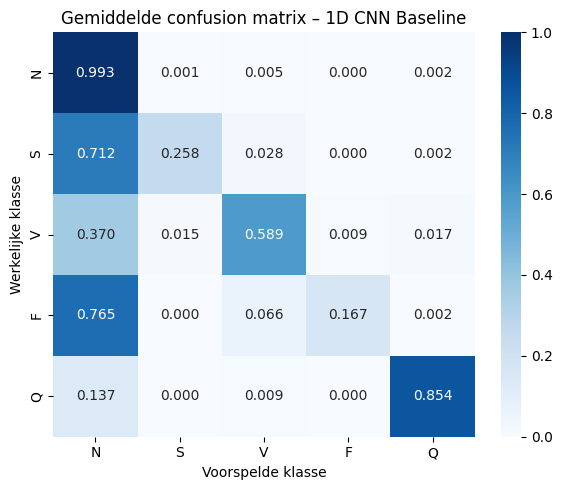

In [7]:
from src.helpers import run_experiment
from src.networks import CNN1D


run_experiment(
    model_function=lambda: CNN1D(
        num_classes=5,
        filters=16,
        input_size=192,
    ),
    experiment_name="1D CNN Baseline",
    trainstreamer=trainstreamer,
    teststreamer=teststreamer,
    loss_fn=nn.CrossEntropyLoss(),
    class_weights=False,
    parallel=False,
    runs=3,
    epochs=5,
    filename="results/results.csv",
)

In [8]:
# ============================================
# Experiment 2 - 1D CNN met class weights
# ============================================

In [9]:
class_counts = torch.bincount(traindataset.y)

class_weights = class_counts.sum() / (
    len(class_counts) * class_counts.float()
)

classes = ["N", "S", "V", "F", "Q"]

for cls, count, weight in zip(classes, class_counts, class_weights):
    print(f"{cls}: count={count}, weight={weight:.3f}")

N: count=72471, weight=0.242
S: count=2223, weight=7.877
V: count=5788, weight=3.025
F: count=641, weight=27.318
Q: count=6431, weight=2.723


2026-07-16 10:20:59.673 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to logs/1D CNN Weighted/run_1/20260716-102059



1D CNN Weighted - run 1


100%|██████████| 547/547 [00:02<00:00, 261.76it/s]
2026-07-16 10:21:03.343 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.9839 test 0.9228 metric ['0.5404', '0.5404', '0.3709', '0.5404', '0.6569']
100%|██████████| 547/547 [00:02<00:00, 271.41it/s]
2026-07-16 10:21:06.912 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.7922 test 0.7760 metric ['0.7675', '0.7675', '0.4821', '0.7675', '0.7284']
100%|██████████| 547/547 [00:02<00:00, 244.12it/s]
2026-07-16 10:21:10.678 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.7192 test 0.7162 metric ['0.7702', '0.7702', '0.4820', '0.7702', '0.7381']
100%|██████████| 547/547 [00:02<00:00, 221.07it/s]
2026-07-16 10:21:14.787 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.6435 test 0.6046 metric ['0.8309', '0.8309', '0.5536', '0.8309', '0.8061']
100%|██████████| 547/547 [00:02<00:00, 193.86it/s]
2026-07-16 10:21:20.122 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.7142 test 0.6340 metric [

Accuracy: 0.614
Recall: [0.571 0.74  0.716 0.866 0.939]
Trainingstijd: 20.5 seconden

1D CNN Weighted - run 2


100%|██████████| 547/547 [00:02<00:00, 249.22it/s]
2026-07-16 10:21:25.698 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.9938 test 0.8742 metric ['0.7601', '0.7601', '0.4814', '0.7601', '0.7166']
100%|██████████| 547/547 [00:02<00:00, 264.67it/s]
2026-07-16 10:21:29.350 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.6968 test 0.6737 metric ['0.8807', '0.8807', '0.6330', '0.8807', '0.7814']
100%|██████████| 547/547 [00:02<00:00, 253.26it/s]
2026-07-16 10:21:33.100 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.6420 test 0.6402 metric ['0.8332', '0.8332', '0.5769', '0.8332', '0.8027']
100%|██████████| 547/547 [00:02<00:00, 250.13it/s]
2026-07-16 10:21:36.863 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.5979 test 0.5693 metric ['0.8614', '0.8614', '0.6187', '0.8614', '0.8431']
100%|██████████| 547/547 [00:02<00:00, 197.59it/s]
2026-07-16 10:21:42.172 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.5783 test 0.5856 metric [

Accuracy: 0.755
Recall: [0.735 0.673 0.817 0.876 0.933]
Trainingstijd: 20.3 seconden

1D CNN Weighted - run 3


100%|██████████| 547/547 [00:03<00:00, 163.77it/s]
2026-07-16 10:21:48.049 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 1.0137 test 0.8327 metric ['0.7086', '0.7086', '0.4328', '0.7086', '0.7226']
100%|██████████| 547/547 [00:02<00:00, 248.81it/s]
2026-07-16 10:21:51.844 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.7660 test 0.7056 metric ['0.6730', '0.6730', '0.4424', '0.6730', '0.7354']
100%|██████████| 547/547 [00:03<00:00, 162.82it/s]
2026-07-16 10:21:56.972 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.6836 test 0.6655 metric ['0.8217', '0.8217', '0.5278', '0.8217', '0.7763']
100%|██████████| 547/547 [00:03<00:00, 167.01it/s]
2026-07-16 10:22:02.067 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.6145 test 0.6104 metric ['0.8451', '0.8451', '0.5848', '0.8451', '0.8177']
100%|██████████| 547/547 [00:02<00:00, 188.30it/s]
2026-07-16 10:22:06.633 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.6138 test 0.5651 metric [

Accuracy: 0.787
Recall: [0.782 0.684 0.758 0.791 0.91 ]
Trainingstijd: 23.6 seconden


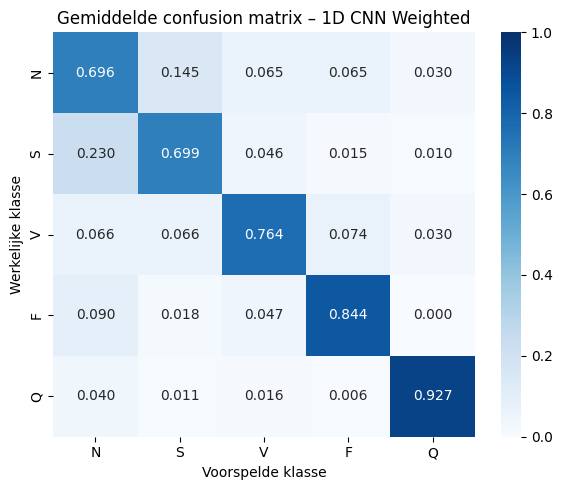

In [10]:
run_experiment(
    model_function=lambda: CNN1D(
        num_classes=5,
        filters=16,
        input_size=192,
    ),
    experiment_name="1D CNN Weighted",
    trainstreamer=trainstreamer,
    teststreamer=teststreamer,
    loss_fn=nn.CrossEntropyLoss(
        weight=class_weights,
    ),
    class_weights=True,
    parallel=False,
    runs=3,
    epochs=5,
    filename="results/results.csv",
)